# Laboratorio 4.2 - Clasificacion Multiclase One-vs-All (Multimodal)
Estudiante: Valencia Medina Freddy Daniel
En este laboratorio se adapta la plantilla de **regresion logistica regularizada One-vs-All** a un problema real de reconocimiento de emociones usando el dataset **CREMA-D**.

A diferencia de la plantilla clasica (solo imagenes de digitos), aqui se construye una representacion **multimodal**:
- Audio: MFCC, Chroma, Spectral Contrast y ZCR (240 features).
- Video: descriptores HOG faciales sobre 15 frames (128 features).
- Fusion final: $n=368$ caracteristicas por ejemplo.

El objetivo es entrenar 6 clasificadores binarios (uno por emocion) y seleccionar la clase con mayor probabilidad.

## 1. Carga y analisis inicial del dataset

Se recorre el directorio de audios para construir un dataframe con dos columnas:
- `Path`: ruta del archivo.
- `Emotion`: etiqueta de emocion extraida del nombre.

Resultado observado en ejecucion:
- Total audios: **7442**.
- Clases detectadas: `ANG`, `DIS`, `FEA`, `HAP`, `NEU`, `SAD`.

In [1]:
# Utilizado para la manipulación de directorios y rutas
import os
import time

# Cálculo científico y vectorial para python
import numpy as np

# Libreria para graficos (De la plantilla original)
from matplotlib import pyplot as plt

# Modulo de optimizacion en scipy (De la plantilla original)
from scipy import optimize

# Procesamiento de datos tabulares (Para cumplir tu requerimiento)
import pandas as pd

# Procesamiento y extracción de características de audio
import librosa

# División de datos (Entrenamiento 80% / Prueba 20%)
from sklearn.model_selection import train_test_split

# Le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

import cv2

from skimage.feature import hog
import random
from IPython.display import Audio, display



print("Librerías importadas correctamente.\n")

# Iniciar el cronómetro
start_time = time.time()

# Ruta exacta a los audios WAV en Kaggle
dataset_path = '/kaggle/input/datasets/orvile/crema-d-emotional-multimodal-dataset/content/CREMA-D/AudioWAV'

# Imprimir la ruta principal del directorio (como solicitaste)
print(f"Directorio base del dataset: {dataset_path}\n")

filepaths = []
labels = []

# Recorrer el directorio y extraer las rutas y emociones
for filename in os.listdir(dataset_path):
    if filename.endswith('.wav'):
        # En CREMA-D, el nombre del archivo tiene el formato: ActorID_Frase_Emocion_Intensidad.wav
        # Al separar por el guión bajo '_', la emoción siempre está en la posición 2
        emotion = filename.split('_')[2]
        
        filepaths.append(os.path.join(dataset_path, filename))
        labels.append(emotion)

# Crear el DataFrame de Pandas
df = pd.DataFrame({
    'Path': filepaths,
    'Emotion': labels
})

# Detener cronómetro
end_time = time.time()

# Mostrar resultados
print(f"Total de audios cargados en memoria: {len(df)}")
print(f"Categorías de emociones encontradas: {df['Emotion'].unique()}")
print(f"Tiempo de ejecución de esta celda: {end_time - start_time:.4f} segundos\n")

# Mostrar las primeras 5 filas para comprobar la estructura
display(df.head())

Librerías importadas correctamente.

Directorio base del dataset: /kaggle/input/datasets/orvile/crema-d-emotional-multimodal-dataset/content/CREMA-D/AudioWAV

Total de audios cargados en memoria: 7442
Categorías de emociones encontradas: ['DIS' 'HAP' 'SAD' 'NEU' 'FEA' 'ANG']
Tiempo de ejecución de esta celda: 0.1635 segundos



,Path,Emotion
0,/kaggle/input/datasets/orvile/crema-d-emotiona...,DIS
1,/kaggle/input/datasets/orvile/crema-d-emotiona...,HAP
2,/kaggle/input/datasets/orvile/crema-d-emotiona...,HAP
3,/kaggle/input/datasets/orvile/crema-d-emotiona...,DIS
4,/kaggle/input/datasets/orvile/crema-d-emotiona...,DIS


## 2. Balanceo y extraccion de features de audio

Primero se balancea por submuestreo con el tamano de la clase minoritaria:
$$m_{balanceado}=6\times 1087=6522$$

Luego se extraen 240 features por audio combinando estadisticas temporales (mean, min, max, std) sobre 60 descriptores base:
- 40 MFCC
- 12 Chroma
- 7 Spectral Contrast
- 1 ZCR

Formalmente:
$$x_{audio}\in\mathbb{R}^{240}$$

Esta etapa esta bien alineada con la plantilla: preprocesamiento + vectorizacion antes de entrenar.

In [2]:
start_time = time.time()

print("Iniciando el balanceo del dataset...")
# 1. Encontrar la cantidad de la clase minoritaria
min_count = df['Emotion'].value_counts().min()
print(f"La clase con menos ejemplos tiene {min_count} audios. Balanceando todas las clases...")

df_balanced = df.groupby('Emotion').sample(n=min_count, random_state=42).reset_index(drop=True)
print(f"Nuevo tamaño del dataset balanceado: {len(df_balanced)} audios en total.\n")

# 2. Función de Extracción Avanzada de Audio (240 propiedades)
def extract_features_advanced(file_path):
    try:
        # Cargar audio (ignorando el primer 0.5 seg de silencio)
        y, sr = librosa.load(file_path, duration=2.5, offset=0.5)
        
        # 1. MFCC (Timbre vocal - 40 variables)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        # 2. Chroma (Tono/Pitch musical - 12 variables)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        # 3. Spectral Contrast (Picos de intensidad/Gritos - 7 variables)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        # 4. Zero Crossing Rate (Ruido/Respiración agitada - 1 variable)
        zcr = librosa.feature.zero_crossing_rate(y)
        
        # Apilamos todas las características (40 + 12 + 7 + 1 = 60 variables a lo largo del tiempo)
        stacked = np.vstack((mfccs, chroma, contrast, zcr))
        
        # Calculamos estadísticas temporales (Pooling)
        feat_mean = np.mean(stacked, axis=1)
        feat_min = np.min(stacked, axis=1)
        feat_max = np.max(stacked, axis=1)
        feat_std = np.std(stacked, axis=1)
        
        # Resultado: 60 variables * 4 estadísticas = 240 propiedades
        return np.hstack((feat_mean, feat_min, feat_max, feat_std))
    except Exception as e:
        # Si falla un audio, devolvemos 240 ceros para no romper la matriz
        return np.zeros(240)

print("Iniciando EXTRACCIÓN de 240 características de AUDIO. Esto tomará varios minutos...")
features_list = []
for i, path in enumerate(df_balanced['Path']):
    features_list.append(extract_features_advanced(path))
    if (i + 1) % 500 == 0:
        print(f"Procesados {i + 1} / {len(df_balanced)} audios...")

X_full_adv = np.array(features_list)
y_full, y_labels = pd.factorize(df_balanced['Emotion'])

print("\nGuardando matriz de audio en CSV de respaldo...")
df_features = pd.DataFrame(X_full_adv)
df_features['Target'] = y_full
df_features.to_csv('/kaggle/working/crema_d_audio_adv_balanced.csv', index=False)

end_time = time.time()
print(f"\n¡Preprocesamiento de AUDIO completado exitosamente!")
print(f"Dimensiones de X_audio: {X_full_adv.shape} -> (m={X_full_adv.shape[0]}, n={X_full_adv.shape[1]})")
print(f"Mapeo de clases: {dict(enumerate(y_labels))}")
print(f"Tiempo total de la celda: {(end_time - start_time)/60:.2f} minutos.")

Iniciando el balanceo del dataset...
La clase con menos ejemplos tiene 1087 audios. Balanceando todas las clases...
Nuevo tamaño del dataset balanceado: 6522 audios en total.

Iniciando EXTRACCIÓN de 240 características de AUDIO. Esto tomará varios minutos...
Procesados 500 / 6522 audios...
Procesados 1000 / 6522 audios...
Procesados 1500 / 6522 audios...
Procesados 2000 / 6522 audios...
Procesados 2500 / 6522 audios...
Procesados 3000 / 6522 audios...
Procesados 3500 / 6522 audios...
Procesados 4000 / 6522 audios...
Procesados 4500 / 6522 audios...
Procesados 5000 / 6522 audios...
Procesados 5500 / 6522 audios...
Procesados 6000 / 6522 audios...


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Procesados 6500 / 6522 audios...

Guardando matriz de audio en CSV de respaldo...

¡Preprocesamiento de AUDIO completado exitosamente!
Dimensiones de X_audio: (6522, 240) -> (m=6522, n=240)
Mapeo de clases: {0: 'ANG', 1: 'DIS', 2: 'FEA', 3: 'HAP', 4: 'NEU', 5: 'SAD'}
Tiempo total de la celda: 5.27 minutos.


## 3. Extraccion de features de video y fusion multimodal

Para cada muestra se extraen descriptores HOG sobre 15 frames distribuidos uniformemente en el video.
Al promediar los vectores por frame se obtiene:
$$x_{video}\in\mathbb{R}^{128}$$

Fusion final por concatenacion:
$$x=[x_{audio};x_{video}]\in\mathbb{R}^{368}$$

Esta decision es razonable para mantener un modelo lineal interpretable, aunque puede perder dinamica temporal fina del video.

In [3]:
print("Iniciando extracción de propiedades de VIDEO con HOG (15 frames)...")
start_time = time.time()

video_features_list = []

for i, audio_path in enumerate(df_balanced['Path']):
    video_path = audio_path.replace('AudioWAV', 'VideoFlash').replace('.wav', '.flv')
    v_features_frames = []

    if os.path.exists(video_path):
        try:
            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

            # Si el video es corto, usamos los frames disponibles en vez de descartarlo.
            if total_frames >= 1:
                n_frames = min(15, total_frames)
                indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)
                for idx in indices:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                    ret, frame = cap.read()
                    if ret:
                        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                        resized = cv2.resize(gray, (64, 64))
                        # Extrae 128 contornos faciales (HOG)
                        fd = hog(resized, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1))
                        v_features_frames.append(fd)
            cap.release()
        except Exception:
            pass  # Si el video esta corrupto, se omite y se rellena con ceros.

    # Pooling temporal de contornos HOG
    if len(v_features_frames) > 0:
        v_features_avg = np.mean(v_features_frames, axis=0)
    else:
        v_features_avg = np.zeros(128)

    video_features_list.append(v_features_avg)

    if (i + 1) % 500 == 0:
        print(f"Procesados {i + 1} / {len(df_balanced)} videos...")

X_video_adv = np.array(video_features_list)
print(f"\nDimensiones extraídas del video (HOG 15 frames): {X_video_adv.shape}")

# Fusión multimodal: Audio (240) + Video (128)
X_multimodal = np.hstack((X_full_adv, X_video_adv))

end_time = time.time()
print(f"Dimensiones de la matriz MULTIMODAL final (X_multimodal): {X_multimodal.shape} -> n={X_multimodal.shape[1]}")
print(f"Tiempo de procesamiento de video: {(end_time - start_time)/60:.2f} minutos.")

Iniciando extracción de propiedades de VIDEO con HOG (15 frames)...
Procesados 500 / 6522 videos...
Procesados 1000 / 6522 videos...
Procesados 1500 / 6522 videos...
Procesados 2000 / 6522 videos...
Procesados 2500 / 6522 videos...
Procesados 3000 / 6522 videos...
Procesados 3500 / 6522 videos...
Procesados 4000 / 6522 videos...
Procesados 4500 / 6522 videos...
Procesados 5000 / 6522 videos...
Procesados 5500 / 6522 videos...
Procesados 6000 / 6522 videos...
Procesados 6500 / 6522 videos...

Dimensiones extraídas del video (HOG 15 frames): (6522, 128)
Dimensiones de la matriz MULTIMODAL final (X_multimodal): (6522, 368) -> n=368
Tiempo de procesamiento de video: 50.89 minutos.


## 4. Split estratificado y normalizacion

Se divide en entrenamiento/prueba con estratificacion para preservar proporciones de clases:
- Train: 80%
- Test: 20%

La normalizacion usa estadisticos del set de entrenamiento ($\mu,\sigma$) y se aplica igual en test:
$$x_{norm}=\frac{x-\mu}{\sigma}$$

Esto evita fuga de informacion (data leakage), por lo que esta parte esta correctamente implementada.

In [4]:
def featureNormalize(X_train, X_test):
    """
    Normaliza las características restando la media y dividiendo por la desviación estándar.
    """
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    
    # Prevenir división por cero si alguna columna tiene varianza 0
    sigma[sigma == 0] = 1
    
    X_train_norm = (X_train - mu) / sigma
    X_test_norm  = (X_test  - mu) / sigma
    
    return X_train_norm, X_test_norm, mu, sigma

print("Función featureNormalize definida correctamente.")

Función featureNormalize definida correctamente.


In [5]:
from sklearn.model_selection import train_test_split

# 1. Creamos una lista de índices (0, 1, 2... hasta el total de ejemplos)
indices_totales = np.arange(len(X_multimodal))

# 2. Dividimos X, y Y TAMBIÉN los índices
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_multimodal, 
    y_full, 
    indices_totales, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_full
)

print(f"Set de Entrenamiento: {X_train.shape[0]} ejemplos")
print(f"Set de Prueba: {X_test.shape[0]} ejemplos (Estos usaremos para la prueba interactiva)")

# 3. Aplicamos tu función de normalización como ya la tenías
X_train_norm, X_test_norm, mu, sigma = featureNormalize(X_train, X_test)

Set de Entrenamiento: 5217 ejemplos
Set de Prueba: 1305 ejemplos (Estos usaremos para la prueba interactiva)


In [6]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

In [7]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de usar theta como parámetro para la regresión logística regularizada.
    """
    m = y.size
    
    # Convierte las etiquetas a valores booleanos/enteros si es necesario
    if y.dtype == bool:
        y = y.astype(int)
    
    J = 0
    grad = np.zeros(theta.shape)
    
    h = sigmoid(X.dot(theta.T))
    
    temp = theta.copy()
    temp[0] = 0 # No regularizamos el término de sesgo (bias)
    
    # Función de costo J
    J = (1 / m) * np.sum(-y.dot(np.log(h + 1e-15)) - (1 - y).dot(np.log(1 - h + 1e-15))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
    
    # Gradiente
    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp
    
    return J, grad

print("Funciones matemáticas (sigmoid, lrCostFunction) cargadas.")

Funciones matemáticas (sigmoid, lrCostFunction) cargadas.


## 5. Regresion logistica One-vs-All regularizada

Se entrenan $K=6$ clasificadores binarios con `scipy.optimize.minimize` (metodo CG).
Para cada clase $c$:
$$h_\theta(x)=\sigma(\theta^Tx)$$
$$J(\theta)=\frac{1}{m}\sum_{i=1}^{m}\left[-y^{(i)}\log(h_\theta(x^{(i)}))-(1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]+\frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2$$

Prediccion final:
$$\hat{y}=\arg\max_c\;h_{\theta^{(c)}}(x)$$



In [8]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)

    all_J_history = [] # Lista maestra para la gráfica
    
    # Diccionario local de emociones para tus prints
    idx_a_clase = {0: 'ANG (Enojo)', 1: 'DIS (Asco)', 2: 'FEA (Miedo)', 
                   3: 'HAP (Felicidad)', 4: 'NEU (Neutral)', 5: 'SAD (Tristeza)'}

    print("Iniciando Entrenamiento Optimizado (SciPy Minimize)...")
    
    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 1000} # Aseguramos que converja

        # Costo inicial
        y_c = (y == c).astype(int)
        J_inicial, _ = lrCostFunction(initial_theta, X_b, y_c, lambda_)
        
        historial_clase = [J_inicial]

        # Inyectamos el Callback para robarle el costo a scipy iteración por iteración
        def save_cost(theta_actual):
            costo, _ = lrCostFunction(theta_actual, X_b, y_c, lambda_)
            historial_clase.append(costo)

        # Optimizador Scipy
        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X_b, y_c, lambda_),
            jac=True,
            method='CG',
            callback=save_cost,
            options=options
        )
        
        all_theta[c] = res.x
        all_J_history.append(historial_clase)

        # Tu bloque de prints estéticos
        J_final = res.fun
        reduccion = ((J_inicial - J_final) / J_inicial) * 100

        print(f'  Clase {c} ({idx_a_clase[c]:15s}) → '
              f'costo inicial: {J_inicial:.4f} | '
              f'costo final: {J_final:.4f} | '
              f'reducción: {reduccion:.1f}%')

    return all_theta, all_J_history



In [9]:
def predictOneVsAll(all_theta, X):
    """Predice la clase con la probabilidad más alta."""
    m = X.shape[0]
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    return np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

print("Funciones de clasificación One-vs-All cargadas correctamente.")

Funciones de clasificación One-vs-All cargadas correctamente.


## 6. Resultados obtenidos y lectura critica

Resultados reportados en tu ejecucion:
- Accuracy entrenamiento: **69.12%**
- Accuracy prueba: **52.18%**

Interpretacion:
- La brecha train-test es moderada

In [10]:
# 1. Entrenar el modelo
lambda_ = 0.01
num_labels = 6
all_theta, all_J_history = oneVsAll(X_train_norm, y_train, num_labels, lambda_)

# 2. Validar efectividad
pred_train = predictOneVsAll(all_theta, X_train_norm)
acc_train = np.mean(pred_train == y_train) * 100

pred_test = predictOneVsAll(all_theta, X_test_norm)
acc_test = np.mean(pred_test == y_test) * 100

print("\n" + "="*55)
print(f"Efectividad en Datos de Entrenamiento (80%): {acc_train:.2f}%")
print(f"Efectividad en Datos de Prueba (20%):      {acc_test:.2f}%")
print("="*55 + "\n")


Iniciando Entrenamiento Optimizado (SciPy Minimize)...
  Clase 0 (ANG (Enojo)    ) → costo inicial: 0.6931 | costo final: 0.1545 | reducción: 77.7%
  Clase 1 (DIS (Asco)     ) → costo inicial: 0.6931 | costo final: 0.3011 | reducción: 56.6%
  Clase 2 (FEA (Miedo)    ) → costo inicial: 0.6931 | costo final: 0.3103 | reducción: 55.2%
  Clase 3 (HAP (Felicidad)) → costo inicial: 0.6931 | costo final: 0.2880 | reducción: 58.4%
  Clase 4 (NEU (Neutral)  ) → costo inicial: 0.6931 | costo final: 0.2604 | reducción: 62.4%
  Clase 5 (SAD (Tristeza) ) → costo inicial: 0.6931 | costo final: 0.2388 | reducción: 65.6%

Efectividad en Datos de Entrenamiento (80%): 69.18%
Efectividad en Datos de Prueba (20%):      51.88%



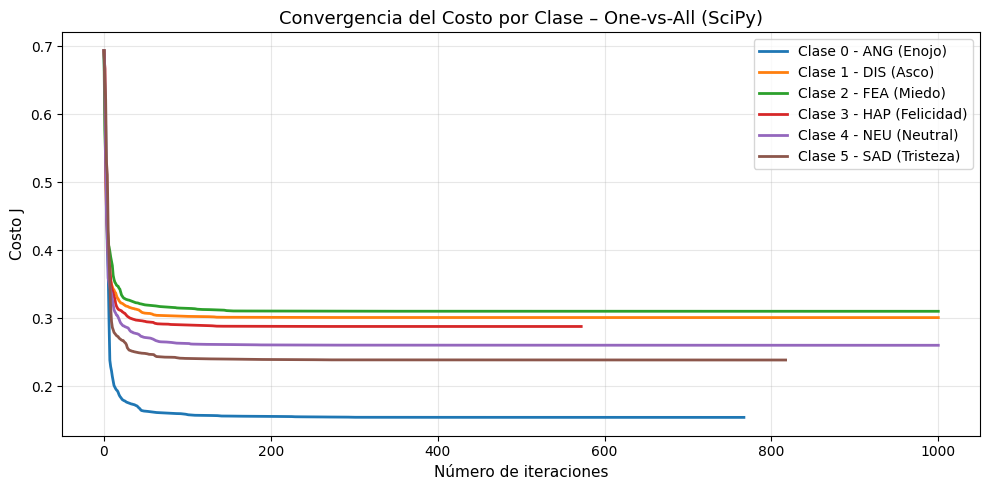

In [11]:

# 3. Graficar la convergencia del costo (Tu código adaptado)
idx_a_clase = {0: 'ANG (Enojo)', 1: 'DIS (Asco)', 2: 'FEA (Miedo)', 
               3: 'HAP (Felicidad)', 4: 'NEU (Neutral)', 5: 'SAD (Tristeza)'}

plt.figure(figsize=(10, 5))

for c in range(num_labels):
    plt.plot(
        np.arange(len(all_J_history[c])),
        all_J_history[c],
        lw=2,
        label=f'Clase {c} - {idx_a_clase[c]}'
    )

plt.xlabel('Número de iteraciones', fontsize=11)
plt.ylabel('Costo J', fontsize=11)
plt.title('Convergencia del Costo por Clase – One-vs-All (SciPy)', fontsize=13)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Iniciando generación MANUAL de la Curva de Aprendizaje...
Iniciando Entrenamiento Optimizado (SciPy Minimize)...
  Clase 0 (ANG (Enojo)    ) → costo inicial: 0.6931 | costo final: 0.0091 | reducción: 98.7%
  Clase 1 (DIS (Asco)     ) → costo inicial: 0.6931 | costo final: 0.0212 | reducción: 96.9%
  Clase 2 (FEA (Miedo)    ) → costo inicial: 0.6931 | costo final: 0.0210 | reducción: 97.0%
  Clase 3 (HAP (Felicidad)) → costo inicial: 0.6931 | costo final: 0.0155 | reducción: 97.8%
  Clase 4 (NEU (Neutral)  ) → costo inicial: 0.6931 | costo final: 0.0181 | reducción: 97.4%
  Clase 5 (SAD (Tristeza) ) → costo inicial: 0.6931 | costo final: 0.0167 | reducción: 97.6%
Con m=500 ejemplos -> Precisión en Test: 37.62%
Iniciando Entrenamiento Optimizado (SciPy Minimize)...
  Clase 0 (ANG (Enojo)    ) → costo inicial: 0.6931 | costo final: 0.0174 | reducción: 97.5%
  Clase 1 (DIS (Asco)     ) → costo inicial: 0.6931 | costo final: 0.0569 | reducción: 91.8%
  Clase 2 (FEA (Miedo)    ) → costo inic

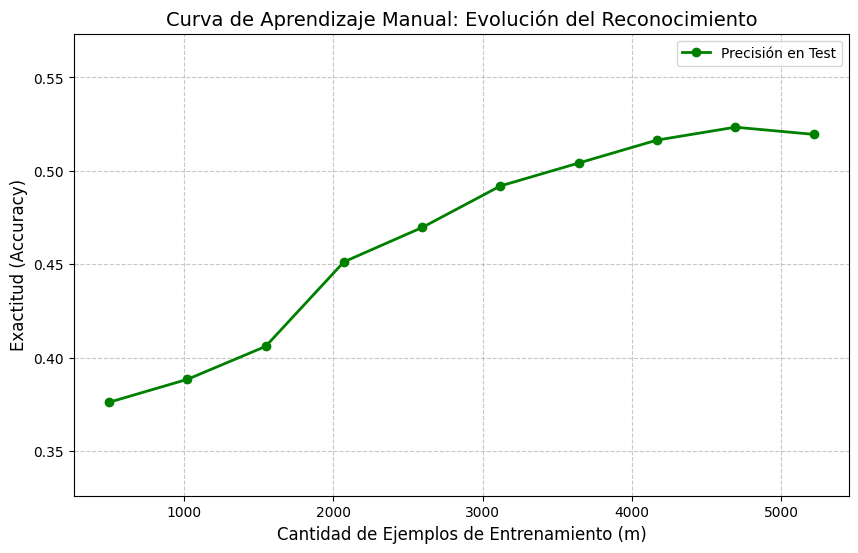

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuramos los puntos de la curva (de 500 en 500 hasta el total)
m_counts = np.linspace(500, len(X_train_norm), 10, dtype=int)
test_accuracies = []

print("Iniciando generación MANUAL de la Curva de Aprendizaje...")

# 2. El Bucle de Entrenamiento Progresivo
for m_subset in m_counts:
    # Tomamos una sub-muestra del set de entrenamiento normalizado
    X_subset = X_train_norm[:m_subset]
    y_subset = y_train[:m_subset]
    
    # Entrenamos el modelo con esta cantidad de datos 'm_subset'
    # Nota: Usamos lambda=0.1 (ajústalo según tu mejor modelo)
    # Recordamos que tu función devuelve: all_theta, all_J_history
    theta_tmp, _ = oneVsAll(X_subset, y_subset, num_labels=6, lambda_=0.1)
    
    # Predecimos sobre el set de TEST completo (los datos que la IA nunca ha visto)
    # Usamos tu función predictOneVsAll
    preds_test = predictOneVsAll(theta_tmp, X_test_norm)
    
    # Calculamos la precisión (Accuracy)
    acc = np.mean(preds_test == y_test)
    test_accuracies.append(acc)
    
    print(f"Con m={m_subset} ejemplos -> Precisión en Test: {acc*100:.2f}%")

# 3. Graficamos con Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(m_counts, test_accuracies, marker='o', linestyle='-', color='green', linewidth=2, label='Precisión en Test')

plt.title("Curva de Aprendizaje Manual: Evolución del Reconocimiento", fontsize=14)
plt.xlabel("Cantidad de Ejemplos de Entrenamiento (m)", fontsize=12)
plt.ylabel("Exactitud (Accuracy)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Ajustamos el eje Y para que se aprecie la subida
plt.ylim([min(test_accuracies) - 0.05, max(test_accuracies) + 0.05])

plt.show()

## Evaluando Mini-Batch de 5 ejemplos aleatorios del Set de Prueba

---

### Prueba #1: `1073_TAI_NEU_XX.wav`

Emocion Real: NEU


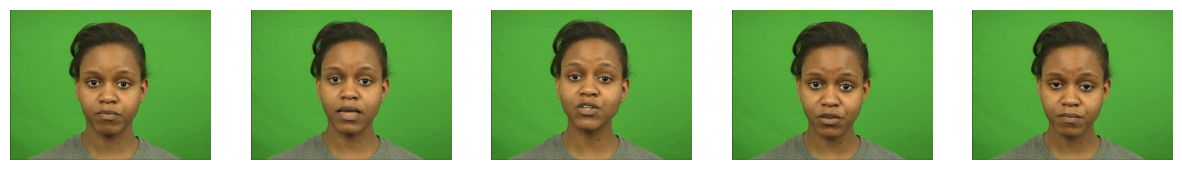

**PREDICCION IA:** `HAP (Felicidad)` <span style='color:red; font-weight:bold;'>Incorrecto</span>

---

### Prueba #2: `1088_ITS_DIS_XX.wav`

Emocion Real: DIS


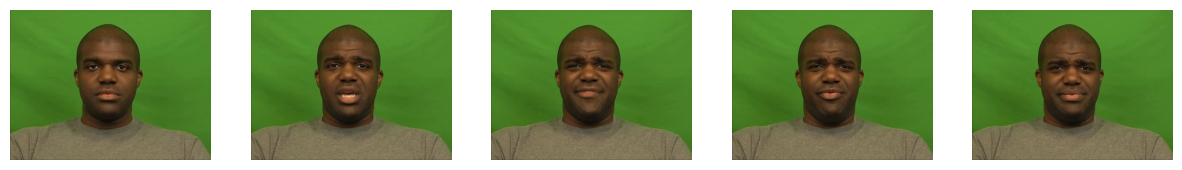

**PREDICCION IA:** `NEU (Neutral)` <span style='color:red; font-weight:bold;'>Incorrecto</span>

---

### Prueba #3: `1023_ITS_DIS_XX.wav`

Emocion Real: DIS


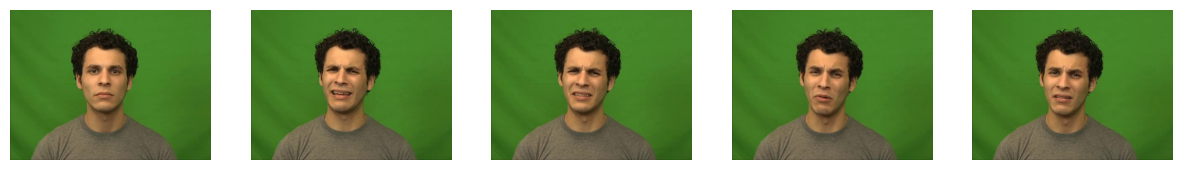

**PREDICCION IA:** `DIS (Asco)` <span style='color:green; font-weight:bold;'>Correcto</span>

---

### Prueba #4: `1053_ITS_FEA_XX.wav`

Emocion Real: FEA


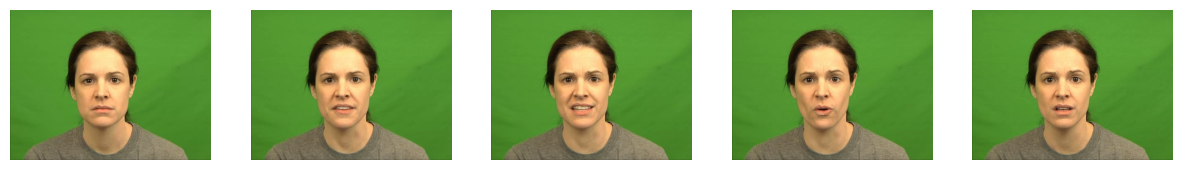

**PREDICCION IA:** `FEA (Miedo)` <span style='color:green; font-weight:bold;'>Correcto</span>

---

### Prueba #5: `1003_ITS_HAP_XX.wav`

Emocion Real: HAP


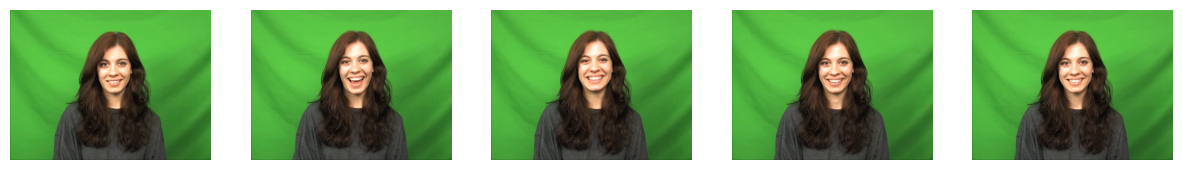

**PREDICCION IA:** `HAP (Felicidad)` <span style='color:green; font-weight:bold;'>Correcto</span>

---

Pruebas de Mini-Batch finalizadas.


In [13]:
import random
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display, Markdown

# 1. Definir cuantas pruebas queremos ver
num_pruebas = 5
idx_a_clase = {0: 'ANG (Enojo)', 1: 'DIS (Asco)', 2: 'FEA (Miedo)',
               3: 'HAP (Felicidad)', 4: 'NEU (Neutral)', 5: 'SAD (Tristeza)'}

display(Markdown(f"## Evaluando Mini-Batch de {num_pruebas} ejemplos aleatorios del Set de Prueba"))

# 2. Bucle para generar las pruebas
for i in range(num_pruebas):
    random_idx = random.randint(0, len(X_test_norm) - 1)

    fila_original = idx_test[random_idx]
    audio_path = df_balanced.iloc[fila_original]['Path']
    video_path = audio_path.replace('AudioWAV', 'VideoFlash').replace('.wav', '.flv')
    etiqueta_real_txt = df_balanced.iloc[fila_original]['Emotion']

    display(Markdown("---"))
    display(Markdown(f"### Prueba #{i+1}: `{os.path.basename(audio_path)}`"))
    print(f"Emocion Real: {etiqueta_real_txt}")

    # Reproducir audio
    display(Audio(audio_path))

    # Mostrar hasta 5 frames representativos
    if os.path.exists(video_path):
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames >= 1:
            n_show = min(5, total_frames)
            indices_f = np.linspace(0, total_frames - 1, n_show, dtype=int)
            fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 2))
            if n_show == 1:
                axes = [axes]
            for j, f_idx in enumerate(indices_f):
                cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
                ret, frame = cap.read()
                if ret:
                    axes[j].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                    axes[j].axis('off')
            plt.show()
        cap.release()

    # Prediccion sobre el modelo entrenado
    x_sample_norm = X_test_norm[random_idx].reshape(1, -1)
    prediccion_num = predictOneVsAll(all_theta, x_sample_norm)[0]
    etiqueta_predicha_txt = idx_a_clase[prediccion_num]

    if etiqueta_real_txt in etiqueta_predicha_txt:
        display(Markdown(f"**PREDICCION IA:** `{etiqueta_predicha_txt}` <span style='color:green; font-weight:bold;'>Correcto</span>"))
    else:
        display(Markdown(f"**PREDICCION IA:** `{etiqueta_predicha_txt}` <span style='color:red; font-weight:bold;'>Incorrecto</span>"))

display(Markdown("---"))
print("Pruebas de Mini-Batch finalizadas.")

Generando Matriz de Confusión para analizar la efectividad por emoción...


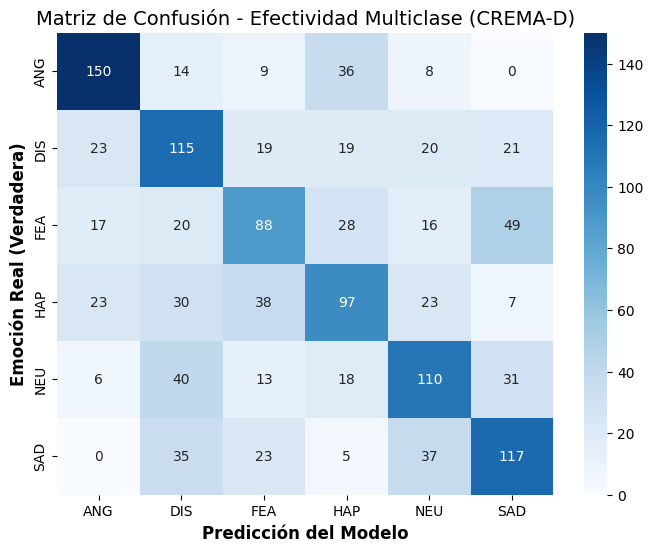

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Generando Matriz de Confusión para analizar la efectividad por emoción...")

# Calcular la matriz usando los datos de prueba (20%) y las predicciones que ya sacaste
cm = confusion_matrix(y_test, pred_test)

# Nombres de las clases para los ejes
nombres_clases = ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

# Dibujar el mapa de calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Emoción Real (Verdadera)', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusión - Efectividad Multiclase (CREMA-D)', fontsize=14)
plt.show()

In [15]:
!pip install gradio

In [16]:
import gradio as gr
import cv2
import numpy as np
import random
import os
import librosa
from skimage.feature import hog
from IPython.display import Audio

# 1. Definimos la función maestra de predicción
def master_predict(video_input, mode):
    idx_a_clase = {0: 'ANG (Enojo)', 1: 'DIS (Asco)', 2: 'FEA (Miedo)', 
                   3: 'HAP (Felicidad)', 4: 'NEU (Neutral)', 5: 'SAD (Tristeza)'}
    
    try:
        if mode == "Dataset Aleatorio":
            idx = random.randint(0, len(df_balanced) - 1)
            audio_path = df_balanced['Path'].iloc[idx]
            
            # Buscamos el video (flv o mp4)
            v_path = audio_path.replace('AudioWAV', 'VideoFlash').replace('.wav', '.flv')
            if not os.path.exists(v_path):
                v_path = v_path.replace('.flv', '.mp4')
            
            real_label = df_balanced['Emotion'].iloc[idx]
            # Inferencia rápida con la matriz ya cargada
            x_norm = (X_multimodal[idx].reshape(1, -1) - mu) / sigma
            
        else:
            # Si el usuario sube un video
            if video_input is None: return None, None, "⚠️ Por favor sube un video primero."
            v_path = video_input
            audio_path = video_input 
            real_label = "Usuario (Inferencia en vivo)"
            
            # --- Extracción de audio ---
            y, sr = librosa.load(v_path, duration=2.5, offset=0.5)
            m = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
            c = librosa.feature.chroma_stft(y=y, sr=sr)
            s = librosa.feature.spectral_contrast(y=y, sr=sr)
            z = librosa.feature.zero_crossing_rate(y)
            stacked = np.vstack((m, c, s, z))
            a_feat = np.hstack((np.mean(stacked, axis=1), np.min(stacked, axis=1), 
                                np.max(stacked, axis=1), np.std(stacked, axis=1)))
            
            # --- Extracción de video ---
            v_feat_frames = []
            cap = cv2.VideoCapture(v_path)
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total > 5:
                indices = np.linspace(0, total - 1, 5, dtype=int)
                for f_idx in indices:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
                    ret, frame = cap.read()
                    if ret:
                        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                        res = cv2.resize(gray, (64, 64))
                        fd = hog(res, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1))
                        v_feat_frames.append(fd)
            cap.release()
            v_feat = np.mean(v_feat_frames, axis=0) if v_feat_frames else np.zeros(128)
            x_norm = (np.hstack((a_feat, v_feat)).reshape(1, -1) - mu) / sigma

        # Predicción Final
        pred_num = predictOneVsAll(all_theta, x_norm)[0]
        pred_label = idx_a_clase[pred_num]
        
        # --- Generar tira de frames (Evita el error de Video de Gradio) ---
        cap = cv2.VideoCapture(v_path)
        total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames_list = []
        if total_f > 5:
            indices = np.linspace(0, total_f - 1, 5, dtype=int)
            for f_idx in indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
                ret, frame = cap.read()
                if ret:
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frame = cv2.resize(frame, (160, 120))
                    frames_list.append(frame)
        cap.release()
        
        # Unimos los frames horizontalmente
        final_strip = np.hstack(frames_list) if frames_list else np.zeros((120, 800, 3), dtype=np.uint8)

        res_txt = f"🎭 Emoción Real: {real_label}\n🤖 Predicción IA: {pred_label}"
        
        # Retornamos Audio, Tira de Imágenes y Texto
        return audio_path, final_strip, res_txt
    
    except Exception as e:
        return None, None, f"❌ Error: {str(e)}"

# --- CONSTRUCCIÓN DE LA INTERFAZ ---
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🧠 IA Multimodal: Reconocimiento de Emociones")
    gr.Markdown("Este sistema analiza audio y geometría facial. El video original (.flv) se muestra como una secuencia de frames para compatibilidad.")
    
    with gr.Row():
        with gr.Column():
            modo = gr.Radio(["Dataset Aleatorio", "Subir mi Video"], label="Selecciona Modo", value="Dataset Aleatorio")
            video_input = gr.Video(label="Sube tu archivo .mp4 (Solo para modo Subir)")
            btn = gr.Button("🔍 Iniciar Análisis", variant="primary")
        
        with gr.Column():
            audio_out = gr.Audio(label="Audio Extraído")
            img_strip = gr.Image(label="Secuencia de Frames Procesados (Visión HOG)")
            res_txt = gr.Textbox(label="Resultado de la Red Neuronal", lines=3)

    btn.click(
        fn=master_predict,
        inputs=[video_input, modo],
        outputs=[audio_out, img_strip, res_txt]
    )

# --- EL FIX CRÍTICO: allowed_paths permite a Gradio leer el input de Kaggle ---
# Cambia la ruta de abajo por la ruta raíz de tu dataset si es diferente
ruta_dataset = "/kaggle/input/datasets/orvile/crema-d-emotional-multimodal-dataset"

demo.launch(
    share=True, 
    allowed_paths=[ruta_dataset, "/kaggle/input"]
)

/tmp/ipykernel_56/1333077978.py:95: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://505efb2f4fe97d5a24.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
import pickle

# Creamos un diccionario con todo lo necesario para la "memoria" del modelo
data_persistencia = {
    'all_theta': all_theta,
    'mu': mu,
    'sigma': sigma,
    'idx_test': idx_test,
    'y_labels': y_labels,
    'X_test_norm': X_test_norm # Opcional, para pruebas rápidas
}

# Guardamos el archivo en la carpeta de trabajo de Kaggle
nombre_archivo = '/kaggle/working/modelo_emociones_multimodal.pkl'

with open(nombre_archivo, 'wb') as f:
    pickle.dump(data_persistencia, f)

print(f"✅ ¡Modelo y parámetros guardados exitosamente en: {nombre_archivo}!")
print("Ahora puedes reiniciar el kernel y cargar estos datos sin volver a procesar nada.")

✅ ¡Modelo y parámetros guardados exitosamente en: /kaggle/working/modelo_emociones_multimodal.pkl!
Ahora puedes reiniciar el kernel y cargar estos datos sin volver a procesar nada.


In [18]:
import pickle
import numpy as np

# Ruta del archivo guardado
nombre_archivo = '/kaggle/working/modelo_emociones_multimodal.pkl'

try:
    with open(nombre_archivo, 'rb') as f:
        modelo_cargado = pickle.load(f)
    
    # Extraemos las variables de vuelta a la memoria de Python
    all_theta = modelo_cargado['all_theta']
    mu = modelo_cargado['mu']
    sigma = modelo_cargado['sigma']
    idx_test = modelo_cargado['idx_test']
    y_labels = modelo_cargado['y_labels']
    X_test_norm = modelo_cargado['X_test_norm']
    
    print("🚀 Modelo cargado correctamente. ¡Listo para inferencia!")
    print(f"Dimensiones de Theta: {all_theta.shape}")
    
except FileNotFoundError:
    print("❌ Error: No se encontró el archivo del modelo. Asegúrate de haber corrido la celda de guardado.")

🚀 Modelo cargado correctamente. ¡Listo para inferencia!
Dimensiones de Theta: (6, 369)
